# Comprensión y Analisis Exploratorio de Datos (EDA)

## Contexto del Problema

Una empresa financiera requiere predecir el comportamiento de Riesgo Crediticio de los nuevos usuarios, usando información histórica de créditos con el fin de aprender patrones y predecir comportamientos futuros

## Objetivo de este Notebook

Se realizar un Análisis Exploratorio de Datos (EDA) permitiendo:

1. Comprender la estructura de nuestros datos
2. Identificar problemas de calidad (valores nulos, outliers, errores)
3. Descubrir patrones y relaciones entre variables
4. Preparar y transformar los datos para el modelado
5. Seleccionar las características más relevantes (feature selection)

In [35]:
# Importando librerias necesarias
import sys
import os
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("src"))

from cargar_datos import cargar_datos

df= cargar_datos()

print("\n Primeras 5 filas del dataset:")
df.head(5)


       tipo_credito    fecha_prestamo  capital_prestado  plazo_meses  \
0                 7  12/21/2024 11:31           3692160           10   
1                 4    4/22/2025 9:47            840000            6   
2                 9    1/8/2026 12:22           5974028           10   
3                 4    8/4/2025 12:04           1671240            6   
4                 9   4/26/2025 11:24           2781636           11   
...             ...               ...               ...          ...   
10758             9   1/19/2025 16:18           2414886           10   
10759             4   1/10/2025 16:40           2916000           24   
10760             4   6/19/2025 14:28           4249200           36   
10761             9    3/2/2025 11:53           1283308           10   
10762             4   12/8/2024 12:46           3915000           12   

       edad_cliente   tipo_laboral  salario_cliente  total_otros_prestamos  \
0                42  Independiente          8000000      

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,12/21/2024 11:31,3692160,10,42,Independiente,8000000,2500000,341296,88.768094,...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,4/22/2025 9:47,840000,6,60,Empleado,3000000,2000000,124876,95.227787,...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,1/8/2026 12:22,5974028,10,36,Independiente,4036000,829000,529554,47.613894,...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,8/4/2025 12:04,1671240,6,48,Empleado,1524547,498000,252420,95.227787,...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,4/26/2025 11:24,2781636,11,44,Empleado,5000000,4000000,217037,95.227787,...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


In [4]:
# Estadísticas descriptivas para variables numéricas
df.describe()

,tipo_credito,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,Pago_atiempo
count,10763.000000,1.076300e+04,10763.000000,10763.000000,1.076300e+04,1.076300e+04,1.076300e+04,10763.000000,10757.000000,10763.000000,10763.000000,10607.000000,1.060700e+04,1.035800e+04,10173.000000,10763.000000,10763.000000,10763.000000,7.833000e+03,10763.000000
mean,5.411131,2.434315e+06,10.575583,43.948620,1.721643e+07,6.238870e+06,2.436174e+05,91.170036,780.790834,5.726749,4.228561,7.746017,4.593741e+04,4.034617e+04,0.260002,2.779987,0.269813,1.302704,2.005157e+06,0.952523
std,2.338279,1.909643e+06,6.632082,15.060877,3.554767e+08,1.184183e+08,2.104937e+05,16.465441,104.878031,3.977162,3.064683,225.955117,1.062698e+05,7.124244e+04,21.772917,2.748807,0.716471,1.824430,2.144116e+06,0.212668
min,4.000000,3.600000e+05,2.000000,19.000000,0.000000e+00,0.000000e+00,2.394400e+04,-38.009990,-7.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,4.000000,1.224831e+06,6.000000,33.000000,2.000000e+06,5.000000e+05,1.210415e+05,95.227787,757.000000,3.000000,2.000000,0.000000,2.898000e+03,2.690000e+03,0.000000,1.000000,0.000000,0.000000,9.251570e+05,1.000000
50%,4.000000,1.921920e+06,10.000000,42.000000,3.000000e+06,1.000000e+06,1.828630e+05,95.227787,791.000000,5.000000,4.000000,0.000000,1.617800e+04,1.444250e+04,0.000000,2.000000,0.000000,1.000000,1.204496e+06,1.000000
75%,9.000000,3.084840e+06,12.000000,53.000000,4.875808e+06,2.000000e+06,2.878335e+05,95.227787,825.000000,8.000000,6.000000,0.000000,5.298200e+04,4.763225e+04,0.000000,4.000000,0.000000,2.000000,2.231859e+06,1.000000
max,68.000000,4.144415e+07,90.000000,123.000000,2.200000e+10,6.787675e+09,3.816752e+06,95.227787,999.000000,62.000000,29.000000,12534.000000,5.116066e+06,1.562285e+06,2145.000000,51.000000,13.000000,25.000000,3.810658e+07,1.000000


In [5]:
# Caracterización de los datos

# 1. estructura de los datos
resumen_caracterizacion = pd.DataFrame({
    'Columna': df.columns,
    'Tipo': df.dtypes.values,
    'Valores_Unicos': [df[col].nunique() for col in df.columns],
    'Nulos': [df[col].isnull().sum() for col in df.columns],
    '%_Nulos': [round(df[col].isnull().sum() / len(df) * 100, 2) for col in df.columns]
})

# 2. Se añade una columna de "posible Caracterización" basada en reglas lógicas
def sugerir_tipo(row):
    # Si solo tiene 2 valores únicos, es probable que sea Dicotómica
    if row['Valores_Unicos'] == 2:
        return 'Categórica Dicotómica'
    # Si es objeto (texto) y tiene pocos valores únicos, es Nominal o Politómica
    elif row['Tipo'] == 'object' or row['Tipo'] == 'category':
        return 'Categórica Nominal / Politómica'
    # Si es número y tiene muchos valores únicos, es Continua
    elif 'int' in str(row['Tipo']) or 'float' in str(row['Tipo']):
        if row['Valores_Unicos'] > 15:
            return 'Numérica Continua'
        else:
            return 'Numérica Discreta (u Ordinal)'
    return 'Revisar manualmente'

resumen_caracterizacion['Sugerencia'] = resumen_caracterizacion.apply(sugerir_tipo, axis=1)

# Mostramos el resultado
print("Resumen de Caracterización Inicial:")
display(resumen_caracterizacion)

Resumen de Caracterización Inicial:


,Columna,Tipo,Valores_Unicos,Nulos,%_Nulos,Sugerencia
0,tipo_credito,int64,6,0,0.00,Numérica Discreta (u Ordinal)
1,fecha_prestamo,object,10444,0,0.00,Categórica Nominal / Politómica
2,capital_prestado,int64,7306,0,0.00,Numérica Continua
3,plazo_meses,int64,18,0,0.00,Numérica Continua
4,edad_cliente,int64,54,0,0.00,Numérica Continua
5,tipo_laboral,object,2,0,0.00,Categórica Dicotómica
6,salario_cliente,int64,1385,0,0.00,Numérica Continua
7,total_otros_prestamos,int64,1538,0,0.00,Numérica Continua
8,cuota_pactada,int64,9836,0,0.00,Numérica Continua
9,puntaje,float64,248,0,0.00,Numérica Continua


In [6]:
# duplicados
print(f"Cantidad de registros duplicados: {df.duplicated().sum()}")

Cantidad de registros duplicados: 0


In [7]:
# Verificar valores nulos en cada columna
df.isnull().sum()

nulls = (df.isnull().sum() / len(df)) * 100
nulls = nulls.sort_values(ascending=False)
nulls

tendencia_ingresos               27.241475
promedio_ingresos_datacredito    27.222893
saldo_mora_codeudor               5.481743
saldo_principal                   3.762891
saldo_total                       1.449410
saldo_mora                        1.449410
puntaje_datacredito               0.055747
tipo_credito                      0.000000
huella_consulta                   0.000000
creditos_sectorReal               0.000000
creditos_sectorCooperativo        0.000000
creditos_sectorFinanciero         0.000000
cant_creditosvigentes             0.000000
fecha_prestamo                    0.000000
puntaje                           0.000000
cuota_pactada                     0.000000
total_otros_prestamos             0.000000
salario_cliente                   0.000000
tipo_laboral                      0.000000
edad_cliente                      0.000000
plazo_meses                       0.000000
capital_prestado                  0.000000
Pago_atiempo                      0.000000
dtype: floa

Limpieza del Dataframe

In [8]:
# copia del Datafrme para realizar la limpieza y transformación

df_clean = df.copy()

In [9]:
#  Unificación de los nulos

# 1.Limpieza de espacios en blanco en textos
# Esto convierte "  " o " N/A " en "" o "N/A" para que tu lista los encuentre.
df_clean = df_clean.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# 2. unificación nulos
valores_nulos = ["", " ", "NA", "N/A", "null", "NULL", "nan"]
df_clean = df_clean.replace(valores_nulos, np.nan)

# 3. Verificación
print("Conteo de nulos por columna:")
print(df_clean.isnull().sum())

Conteo de nulos por columna:
tipo_credito                        0
fecha_prestamo                      0
capital_prestado                    0
plazo_meses                         0
edad_cliente                        0
tipo_laboral                        0
salario_cliente                     0
total_otros_prestamos               0
cuota_pactada                       0
puntaje                             0
puntaje_datacredito                 6
cant_creditosvigentes               0
huella_consulta                     0
saldo_mora                        156
saldo_total                       156
saldo_principal                   405
saldo_mora_codeudor               590
creditos_sectorFinanciero           0
creditos_sectorCooperativo          0
creditos_sectorReal                 0
promedio_ingresos_datacredito    2930
tendencia_ingresos               2932
Pago_atiempo                        0
dtype: int64


In [10]:
# Conversión de datos a tipos correctos 

# 1. Convertir columna de fecha (texto a formato datetime) (1 columna)
df_clean['fecha_prestamo'] = pd.to_datetime(df_clean['fecha_prestamo'])

# 2. Convertir variables categoricas (4 columnas)
columnas_categoricas = ['tipo_credito', 'tipo_laboral', 'Pago_atiempo', 'tendencia_ingresos']
for col in columnas_categoricas:
    df_clean[col] = df_clean[col].astype('category')

# 3. Convertir variables numéricas (18 columnas)
# Usamos 'errors=coerce' por seguridad en nulos
columnas_numericas = [
    'capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente',
    'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito',
    'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total', 
    'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero', 
    'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito'
]
for col in columnas_numericas:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Verificación de conteo total
print(f"Total columnas: {len(df_clean.columns)}")
print("-" * 30)
print(df_clean.dtypes)

Total columnas: 23
------------------------------
tipo_credito                           category
fecha_prestamo                   datetime64[ns]
capital_prestado                          int64
plazo_meses                               int64
edad_cliente                              int64
tipo_laboral                           category
salario_cliente                           int64
total_otros_prestamos                     int64
cuota_pactada                             int64
puntaje                                 float64
puntaje_datacredito                     float64
cant_creditosvigentes                     int64
huella_consulta                           int64
saldo_mora                              float64
saldo_total                             float64
saldo_principal                         float64
saldo_mora_codeudor                     float64
creditos_sectorFinanciero                 int64
creditos_sectorCooperativo                int64
creditos_sectorReal                   

Diligenciamiento y tratamiento de los nulos

In [11]:
# 1. Lista de columnas que reportaron nulos 
columnas_con_nulos = [
    'puntaje_datacredito', 
    'saldo_mora', 
    'saldo_total', 
    'saldo_principal', 
    'saldo_mora_codeudor', 
    'promedio_ingresos_datacredito'
]

# Rellenamos cada columna con su respectiva mediana
for col in columnas_con_nulos:
    mediana_valor = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(mediana_valor)
    print(f"- {col}: Rellenado con la mediana -> {mediana_valor}")

# 2. La 'tendencia_ingresos' es un caso especial ya que es category
# no es numérica por lo tanto se rellena con la "Moda" (el valor que más se repite)
moda_tendencia = df_clean['tendencia_ingresos'].mode()[0]
df_clean['tendencia_ingresos'] = df_clean['tendencia_ingresos'].fillna(moda_tendencia)
print(f"- tendencia_ingresos: Rellenado con la moda -> {moda_tendencia}")

# Verificación final
print("\nConteo final de nulos:")
print(df_clean.isnull().sum().sum()) 

- puntaje_datacredito: Rellenado con la mediana -> 791.0
- saldo_mora: Rellenado con la mediana -> 0.0
- saldo_total: Rellenado con la mediana -> 16178.0
- saldo_principal: Rellenado con la mediana -> 14442.5
- saldo_mora_codeudor: Rellenado con la mediana -> 0.0
- promedio_ingresos_datacredito: Rellenado con la mediana -> 1204496.0
- tendencia_ingresos: Rellenado con la moda -> Creciente

Conteo final de nulos:
0


Eliminación columnas

In [12]:
# Eliminar la columna saldo_mora_codeudor (no aporta valor pues son los mismo valores de la columna saldo_mora y la mayoria de datos se encuentran vacios)
# Eliminar la columna tendencia_ingreso puesto que contiene cifras en valores y tambien en texto, es decir no hay homogneidad en los datos.
df_clean.drop(columns=['saldo_mora_codeudor','tendencia_ingresos'], inplace=True)

# Verificación que ya no esté en el conteo de columnas
print(f"Total de columnas actual: {len(df_clean.columns)}")
if 'saldo_mora_codeudor' not in df_clean.columns:
    print("Columna 'saldo_mora_codeudor' y 'tendencia_ingresos' eliminada con éxito.")

Total de columnas actual: 21
Columna 'saldo_mora_codeudor' y 'tendencia_ingresos' eliminada con éxito.


In [13]:
# Convertir variables numericas columnas float a enteros 
# Lista de columnas que están en float que serán int
columnas_a_entero = [
    'puntaje_datacredito', 
    'saldo_mora', 
    'saldo_total', 
    'saldo_principal', 
    'promedio_ingresos_datacredito'
]

# Conversión definitiva
for col in columnas_a_entero:
    df_clean[col] = df_clean[col].astype(int)

# Verificación de tipos
print("Nuevos tipos de datos (confirmación de enteros):")
print(df_clean[columnas_a_entero].dtypes)

# Vista previa para ver que ya no tienen el .0
df_clean[columnas_a_entero].head()

Nuevos tipos de datos (confirmación de enteros):
puntaje_datacredito              int32
saldo_mora                       int32
saldo_total                      int32
saldo_principal                  int32
promedio_ingresos_datacredito    int32
dtype: object


,puntaje_datacredito,saldo_mora,saldo_total,saldo_principal,promedio_ingresos_datacredito
0,695,0,51258,51258,908526
1,789,0,8673,8673,939017
2,740,0,18702,18702,1204496
3,837,0,15782,15782,1536193
4,771,0,204804,204804,933473


Resumen del resultado de la limpieza del Dataframe

In [14]:
# 1. Definimos las listas según el análisis que hicimos
dicotomicas = ['Pago_atiempo'] # Solo dos opciones: 0 o 1 (Sí/No)
nominales = ['tipo_credito', 'tipo_laboral'] # Categorías sin orden específico

# 2. Creamos el resumen
resumen_detallado = pd.DataFrame({
    'Columna': df_clean.columns,
    'Tipo_Dato': df_clean.dtypes.values,
    'Nulos': [df_clean[col].isnull().sum() for col in df_clean.columns]
})

# 3. Función para asignar la caracterización específica
def caracterizacion_especifica(col):
    if col == 'fecha_prestamo':
        return 'Temporal'
    elif col in dicotomicas:
        return 'Categórica Dicotómica'
    elif col in nominales:
        return 'Categórica Nominal (Politómica)'
    elif col in ['cant_creditosvigentes', 'huella_consulta', 'puntaje', 'puntaje_datacredito']:
        return 'Numérica Discreta'
    else:
        return 'Numérica Continua'

resumen_detallado['Caracterización'] = resumen_detallado['Columna'].apply(caracterizacion_especifica)

# Mostramos el resultado final
print(" CARACTERIZACIÓN DETALLADA DE VARIABLES")
display(resumen_detallado)

 CARACTERIZACIÓN DETALLADA DE VARIABLES


,Columna,Tipo_Dato,Nulos,Caracterización
0,tipo_credito,category,0,Categórica Nominal (Politómica)
1,fecha_prestamo,datetime64[ns],0,Temporal
2,capital_prestado,int64,0,Numérica Continua
3,plazo_meses,int64,0,Numérica Continua
4,edad_cliente,int64,0,Numérica Continua
5,tipo_laboral,category,0,Categórica Nominal (Politómica)
6,salario_cliente,int64,0,Numérica Continua
7,total_otros_prestamos,int64,0,Numérica Continua
8,cuota_pactada,int64,0,Numérica Continua
9,puntaje,float64,0,Numérica Discreta


Variable Objetivo: PAGO A TIEMPO

Distribución de la Variable Objetivo:
Pago_atiempo
1    10252
0      511
Name: count, dtype: int64

Porcentaje de la Variable Objetivo:
Pago_atiempo
1    95.252253
0     4.747747
Name: proportion, dtype: float64


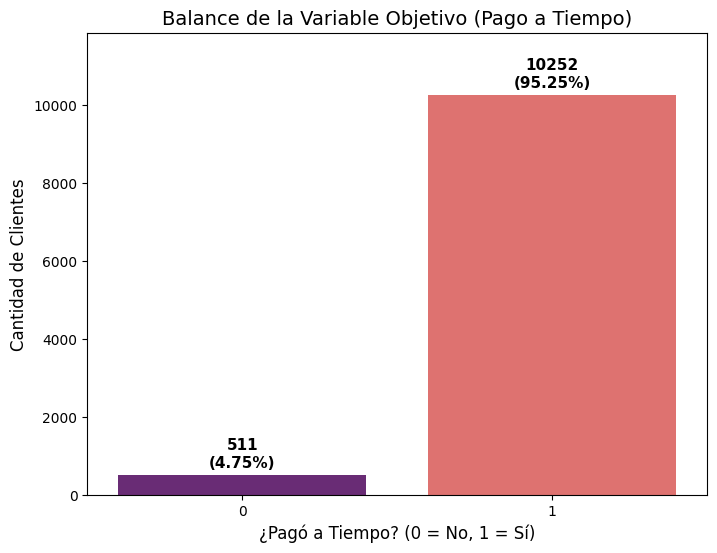

In [15]:
# 1. Distribución en números exactos y en porcentaje
print("Distribución de la Variable Objetivo:")
print(df_clean['Pago_atiempo'].value_counts())
print("\nPorcentaje de la Variable Objetivo:")
print(df_clean['Pago_atiempo'].value_counts(normalize=True) * 100)

# Crear el gráfico
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Pago_atiempo', data=df_clean, hue='Pago_atiempo', palette='magma', legend=False)

# Calcular el total para sacar los porcentajes
total = len(df_clean)

# Agregar las etiquetas de cantidad y porcentaje sobre las barras
for p in ax.patches:
    cantidad = int(p.get_height())
    porcentaje = f'{100 * cantidad / total:.2f}%'
    
    # Escribir el texto (Cantidad \n Porcentaje)
    ax.annotate(f'{cantidad}\n({porcentaje})', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 15), # Desplazamiento hacia arriba
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

plt.title('Balance de la Variable Objetivo (Pago a Tiempo)', fontsize=14)
plt.xlabel('¿Pagó a Tiempo? (0 = No, 1 = Sí)', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)

# Ajustar el límite superior del eje Y para que las etiquetas no se corten
plt.ylim(0, total * 1.1) 
plt.show()

Analisis Exploratorio de Datos EDA

Analisis Univariables: Variable Numéricas

In [16]:
# Seleccionamos solo las columnas numéricas
df_num = df_clean.select_dtypes(include=['int32','int64', 'float64'])

# Calculamos estadísticas básicas + asimetría y curtosis
resumen_stats = df_num.describe().T
resumen_stats['skewness'] = df_num.skew()
resumen_stats['kurtosis'] = df_num.kurt()

print(" Análisis Estadístico Univariable:")
display(resumen_stats)


 Análisis Estadístico Univariable:


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
capital_prestado,10763.0,2.434315e+06,1.909643e+06,360000.00000,1.224831e+06,1.921920e+06,3.084840e+06,4.144415e+07,3.723884,35.318093
plazo_meses,10763.0,1.057558e+01,6.632082e+00,2.00000,6.000000e+00,1.000000e+01,1.200000e+01,9.000000e+01,2.459691,7.780121
edad_cliente,10763.0,4.394862e+01,1.506088e+01,19.00000,3.300000e+01,4.200000e+01,5.300000e+01,1.230000e+02,1.934399,7.868936
salario_cliente,10763.0,1.721643e+07,3.554767e+08,0.00000,2.000000e+06,3.000000e+06,4.875808e+06,2.200000e+10,43.776664,2211.230120
total_otros_prestamos,10763.0,6.238870e+06,1.184183e+08,0.00000,5.000000e+05,1.000000e+06,2.000000e+06,6.787675e+09,38.463886,1719.280871
cuota_pactada,10763.0,2.436174e+05,2.104937e+05,23944.00000,1.210415e+05,1.828630e+05,2.878335e+05,3.816752e+06,3.793301,26.650757
puntaje,10763.0,9.117004e+01,1.646544e+01,-38.00999,9.522779e+01,9.522779e+01,9.522779e+01,9.522779e+01,-4.865607,24.081011
puntaje_datacredito,10763.0,7.807965e+02,1.048491e+02,-7.00000,7.570000e+02,7.910000e+02,8.250000e+02,9.990000e+02,-5.646204,39.462237
cant_creditosvigentes,10763.0,5.726749e+00,3.977162e+00,0.00000,3.000000e+00,5.000000e+00,8.000000e+00,6.200000e+01,1.797738,8.623346
huella_consulta,10763.0,4.228561e+00,3.064683e+00,0.00000,2.000000e+00,4.000000e+00,6.000000e+00,2.900000e+01,1.487102,3.998984


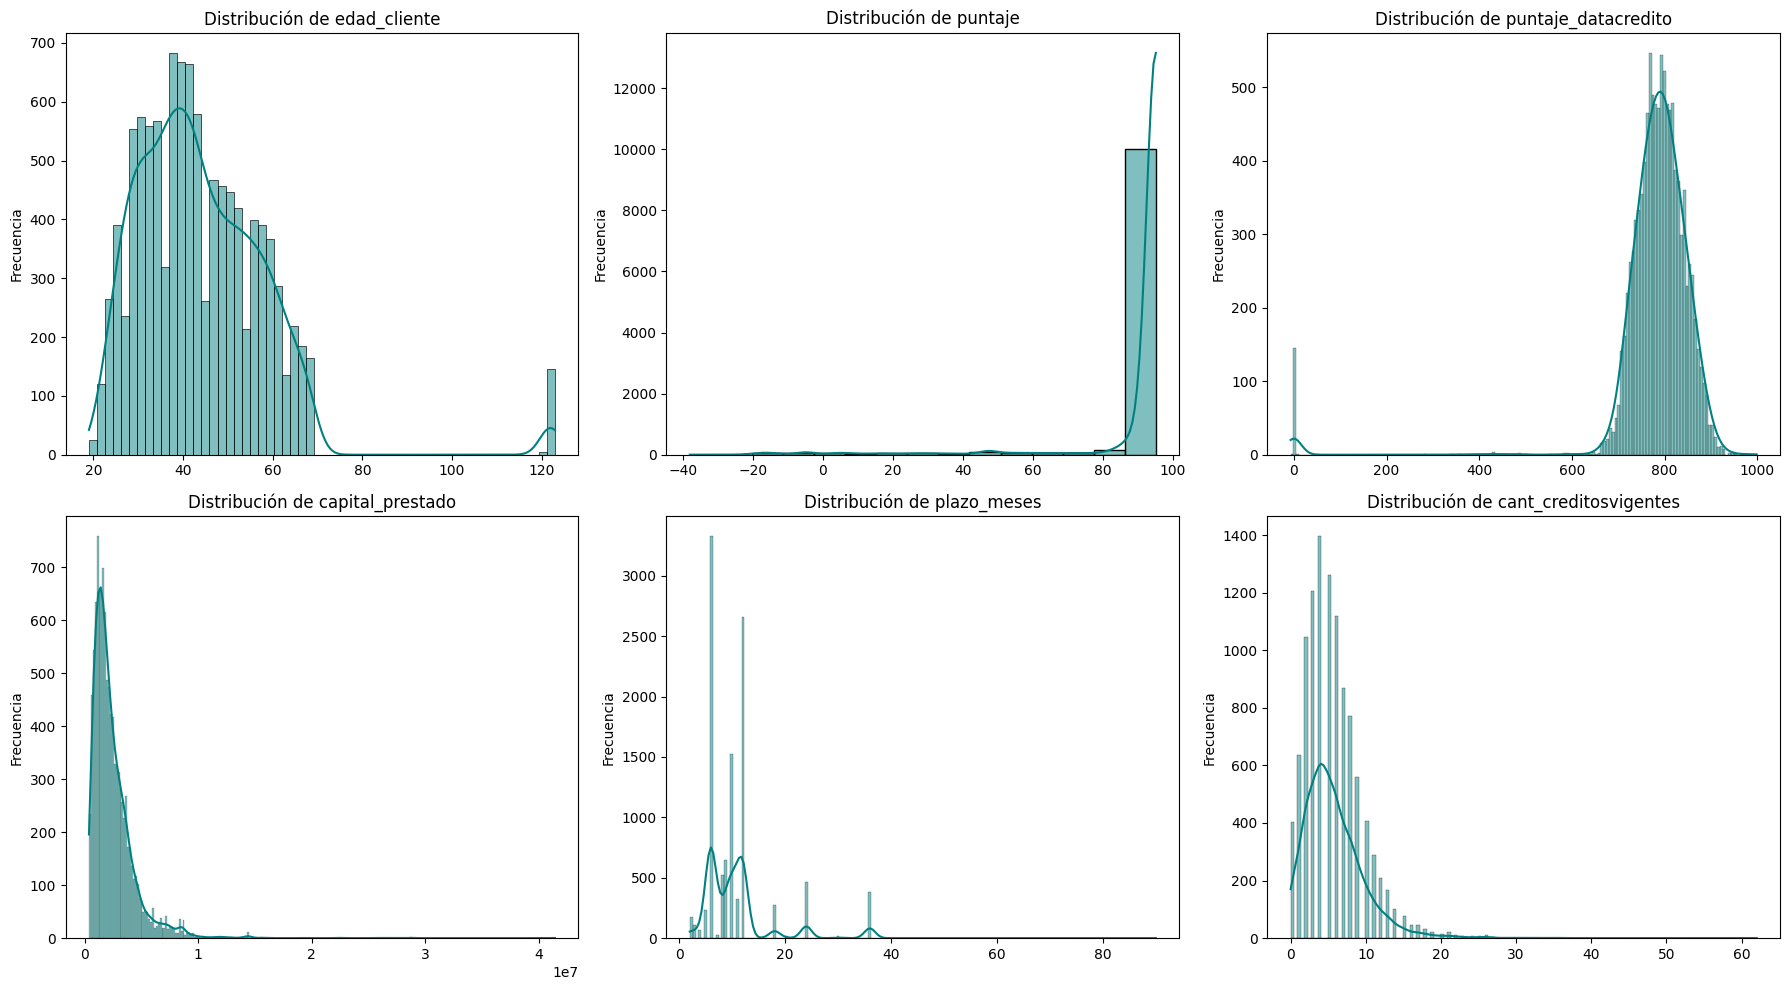

In [17]:
# histograma para las varibales que presentan una distribución normal y se pueden comparar visualmente en cuadricula

cols_grupal = [
    'edad_cliente', 'puntaje', 'puntaje_datacredito', 
    'capital_prestado', 'plazo_meses', 'cant_creditosvigentes'
]

# Creamos una cuadrícula de 2 filas x 3 columnas
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() # Aplanamos para iterar fácilmente

for i, col in enumerate(cols_grupal):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

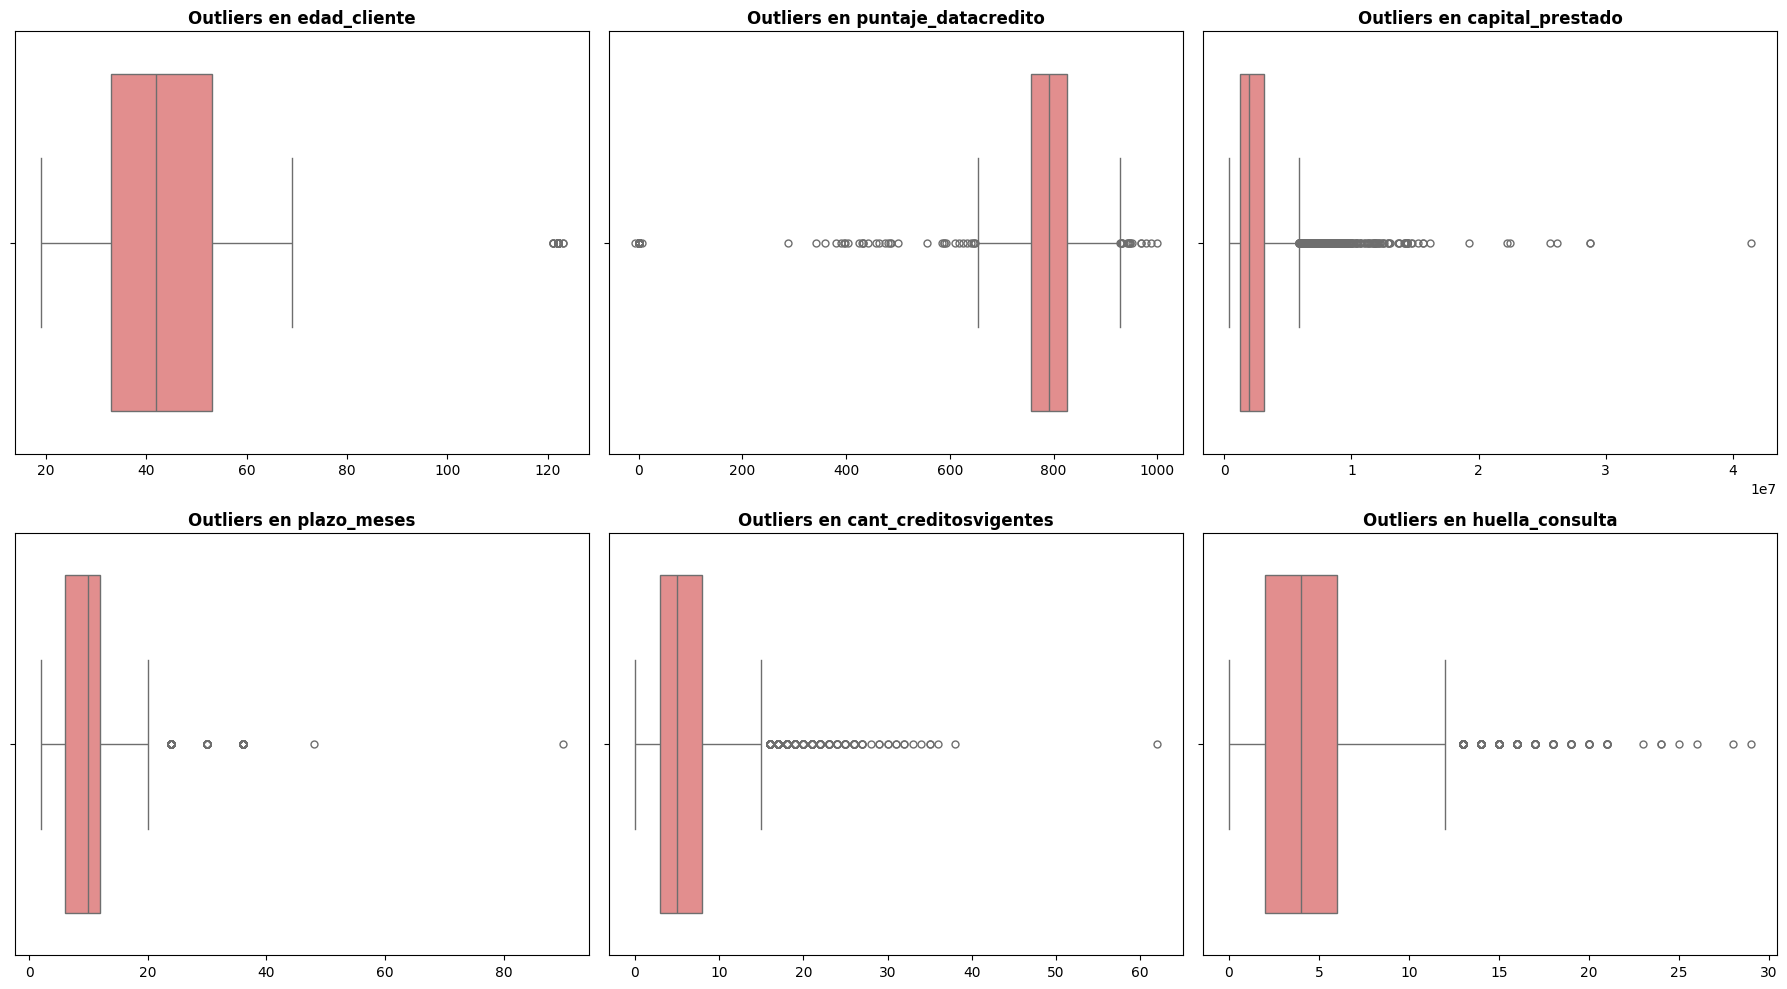

In [18]:
# Visualización de las variables que presentan una distribución normal en un Boxplot

# 1. las variables para el análisis de Outliers
cols_box = [
    'edad_cliente', 'puntaje_datacredito', 'capital_prestado', 
    'plazo_meses', 'cant_creditosvigentes', 'huella_consulta'
]

# 2. Creamos la cuadrícula (2 filas x 3 columnas)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cols_box):
    sns.boxplot(x=df_clean[col], ax=axes[i], color='lightcoral', fliersize=5)
    axes[i].set_title(f'Outliers en {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

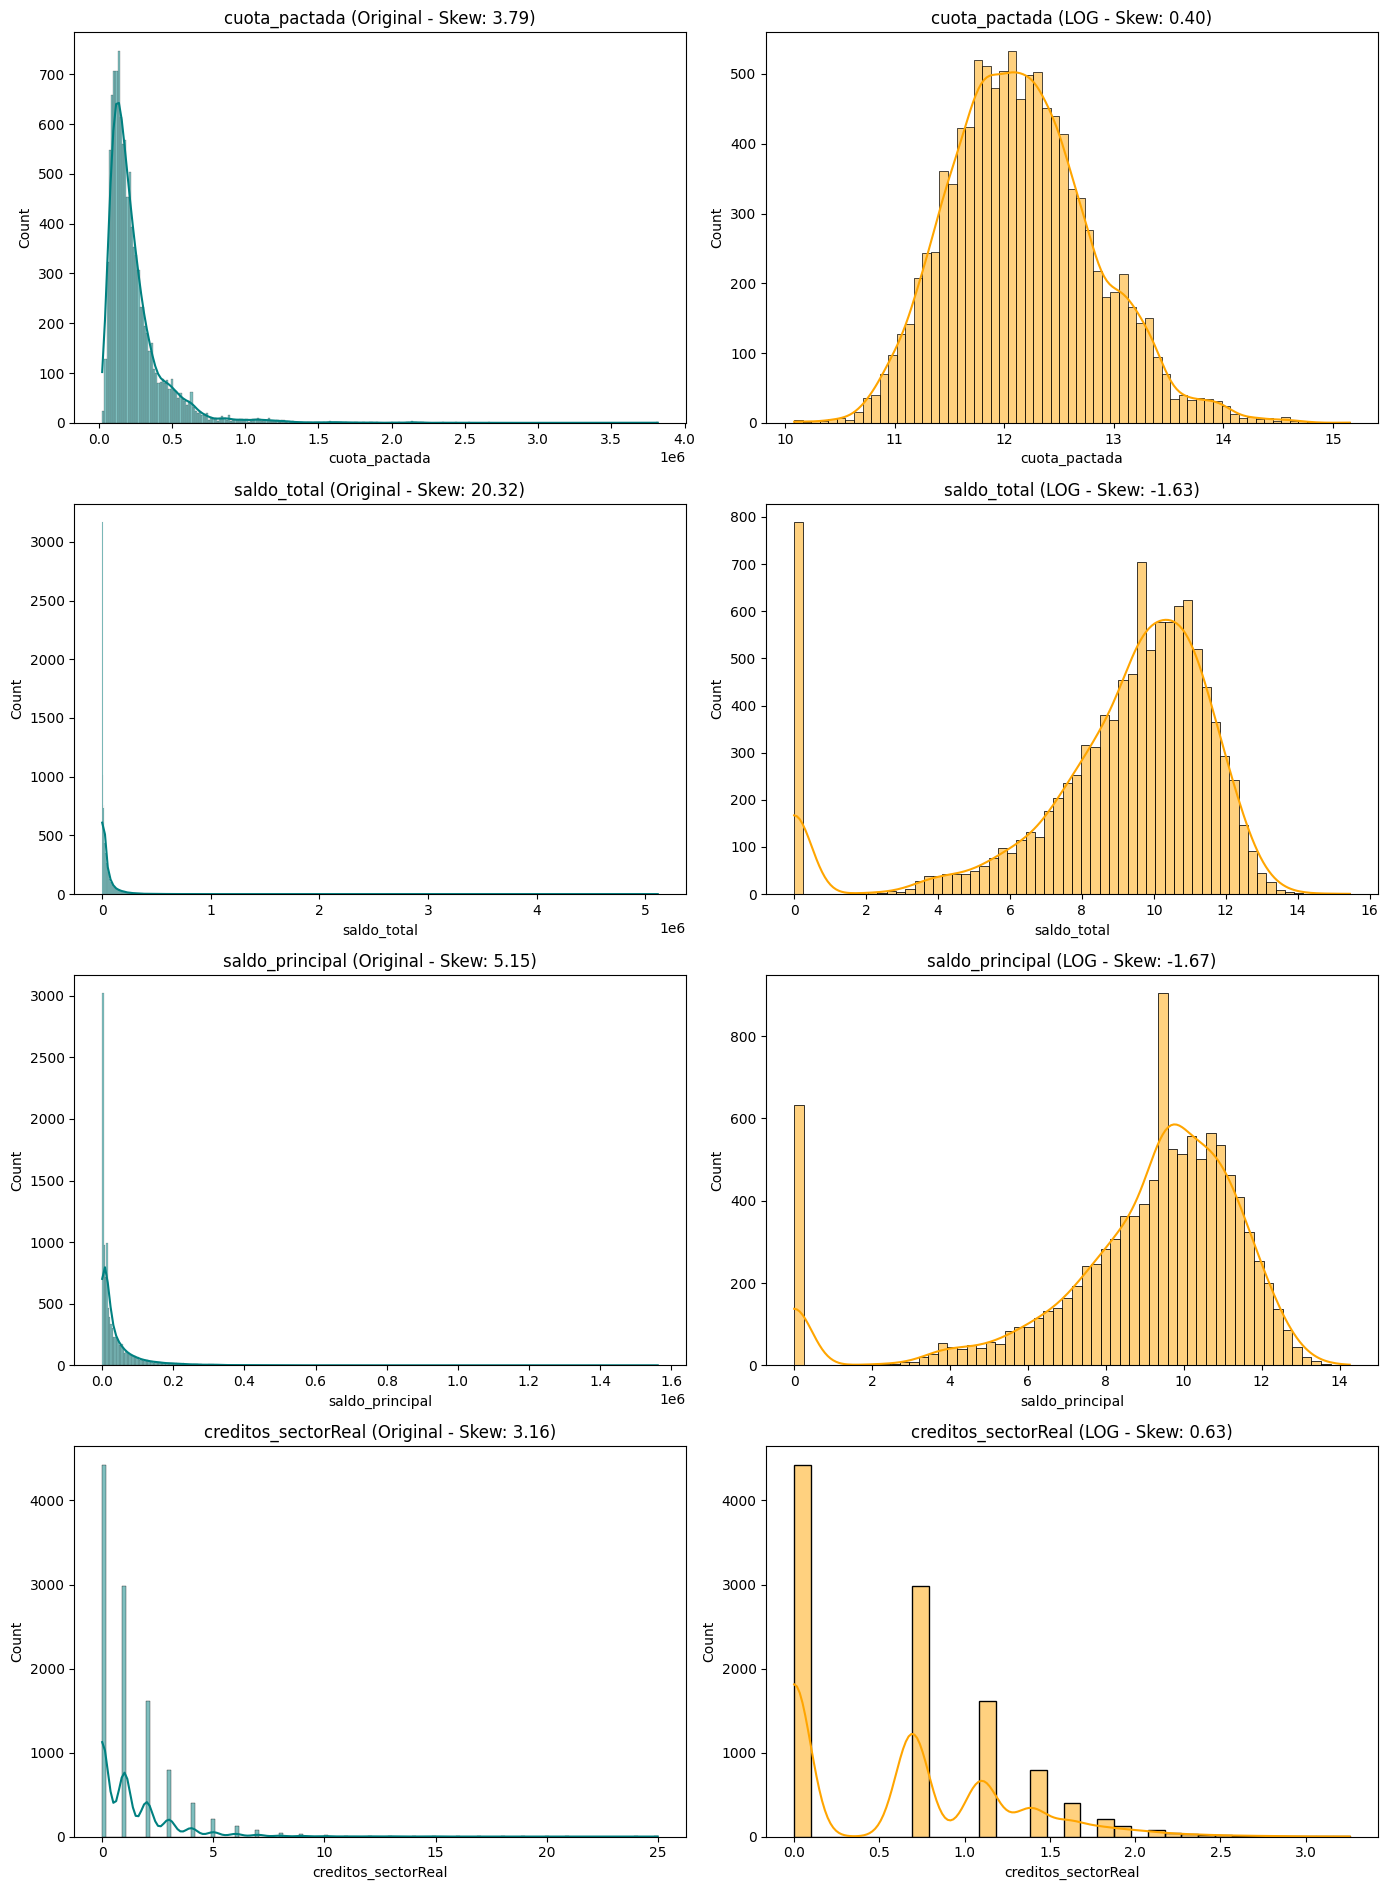

 Reporte de Reducción de Asimetría (Cálculo Temporal):
cuota_pactada: Original 3.79 -> Log 0.40
saldo_total: Original 20.32 -> Log -1.63
saldo_principal: Original 5.15 -> Log -1.67
creditos_sectorFinanciero: Original 2.70 -> Log -0.08
creditos_sectorCooperativo: Original 4.22 -> Log 2.30
creditos_sectorReal: Original 3.16 -> Log 0.63
promedio_ingresos_datacredito: Original 5.08 -> Log -3.91
salario_cliente: Original 43.78 -> Log -4.89
total_otros_prestamos: Original 38.46 -> Log -3.61


In [19]:
# 1.Variables que presentan asimetria (skewness) y kurtosis que impactan
cols_asimetria = [
    'cuota_pactada', 'saldo_total', 'saldo_principal', 
    'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 
    'creditos_sectorReal', 'promedio_ingresos_datacredito', 
    'salario_cliente', 'total_otros_prestamos'
]

# 2. Visualización comparativa (4 más críticas) sin crear columnas permanentes
cols_a_graficar = ['cuota_pactada', 'saldo_total', 'saldo_principal', 'creditos_sectorReal']

fig, axes = plt.subplots(4, 2, figsize=(14, 19))

for i, col in enumerate(cols_a_graficar):
    # --- GRÁFICA ORIGINAL ---
    sns.histplot(df_clean[col], kde=True, ax=axes[i, 0], color='teal')
    axes[i, 0].set_title(f'{col} (Original - Skew: {df_clean[col].skew():.2f})')
    
    # --- GRÁFICA TRANSFORMADA ---
    datos_log = np.log1p(df_clean[col]) # Transformación temporal
    sns.histplot(datos_log, kde=True, ax=axes[i, 1], color='orange')
    axes[i, 1].set_title(f'{col} (LOG - Skew: {datos_log.skew():.2f})')

plt.tight_layout()
plt.show()

# 3. Reporte de Asimetría sin modificar el DataFrame
print(" Reporte de Reducción de Asimetría (Cálculo Temporal):")
for col in cols_asimetria:
    orig_skew = df_clean[col].skew()
    log_skew = np.log1p(df_clean[col]).skew() # Se calcula solo para el print
    print(f"{col}: Original {orig_skew:.2f} -> Log {log_skew:.2f}")

Analisis Univariables: Variables Categoricas


 FRECUENCIAS PARA: tipo_laboral
tipo_laboral
Empleado         6754
Independiente    4009
Name: count, dtype: int64
------------------------------


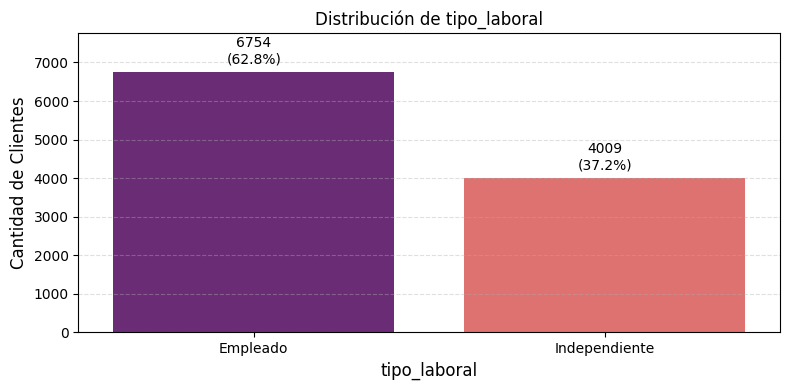


 FRECUENCIAS PARA: tipo_credito
tipo_credito
4     7747
9     2876
10     116
6       21
7        2
68       1
Name: count, dtype: int64
------------------------------


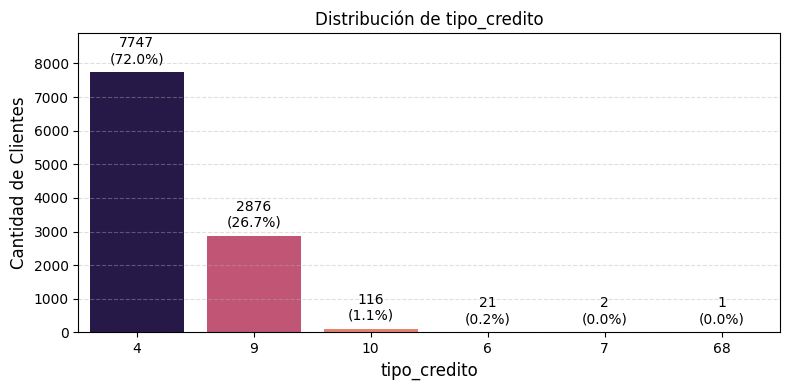


 FRECUENCIAS PARA: Pago_atiempo
Pago_atiempo
1    10252
0      511
Name: count, dtype: int64
------------------------------


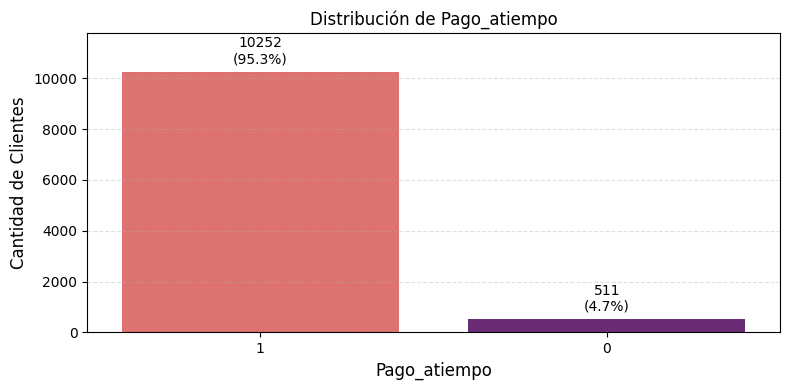

In [20]:
# las variables categóricas

# 1. Definimos las variables categóricas actuales
cols_cat = ['tipo_laboral', 'tipo_credito', 'Pago_atiempo']

# 2. Iteramos para crear la visualización con etiquetas
for col in cols_cat:
    # Frecuencias en consola
    print(f"\n FRECUENCIAS PARA: {col}")
    counts = df_clean[col].value_counts()
    print(counts)
    print("-" * 30)

    # Configuración de la gráfica
    plt.figure(figsize=(8, 4))
    ax = sns.countplot(
        x=col, 
        data=df_clean, 
        order=counts.index, 
        palette='magma',
        hue=col,
        legend=False
    )
    
    # Calcular el total para los porcentajes
    total = len(df_clean)

    # --- AGREGAR NÚMEROS Y PORCENTAJES SOBRE LAS BARRAS ---
    for p in ax.patches:
        cantidad = int(p.get_height())
        porcentaje = f'{(100 * cantidad / total):.1f}%'
        
        # Posicionamos el texto (Cantidad y Porcentaje debajo)
        ax.annotate(f'{cantidad}\n({porcentaje})', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 15), # Desplazamiento vertical
                    textcoords = 'offset points',
                    fontsize=10)

    plt.title(f'Distribución de {col}', fontsize=12)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Cantidad de Clientes', fontsize=12)
    plt.xticks(rotation=0)
    
    # Ajustamos el límite de Y para que las etiquetas no se corten
    plt.ylim(0, counts.max() * 1.15)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    plt.show()


Analisis Bivariable: relación con la variable objetivo

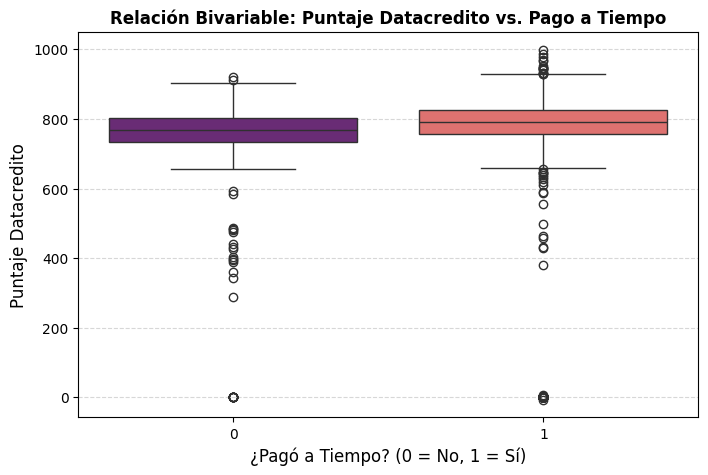

 Medianas de puntaje por grupo:
Pago_atiempo
0    768.0
1    792.0
Name: puntaje_datacredito, dtype: float64


In [21]:
# comparación de variable numericas puntaje_datacredito frente a la variable objetivo

# Configuración del gráfico
plt.figure(figsize=(8, 5))

# Creamos el Boxplot comparativo
sns.boxplot(
    x='Pago_atiempo', 
    y='puntaje_datacredito', 
    data=df_clean, 
    hue='Pago_atiempo',
    palette='magma', 
    legend=False
)

# Añadimos títulos y etiquetas claras
plt.title('Relación Bivariable: Puntaje Datacredito vs. Pago a Tiempo', fontsize=12, fontweight='bold')
plt.xlabel('¿Pagó a Tiempo? (0 = No, 1 = Sí)', fontsize=12)
plt.ylabel('Puntaje Datacredito', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# Resumen numérico para apoyar la gráfica
print(" Medianas de puntaje por grupo:")
print(df_clean.groupby('Pago_atiempo', observed=False)['puntaje_datacredito'].median())

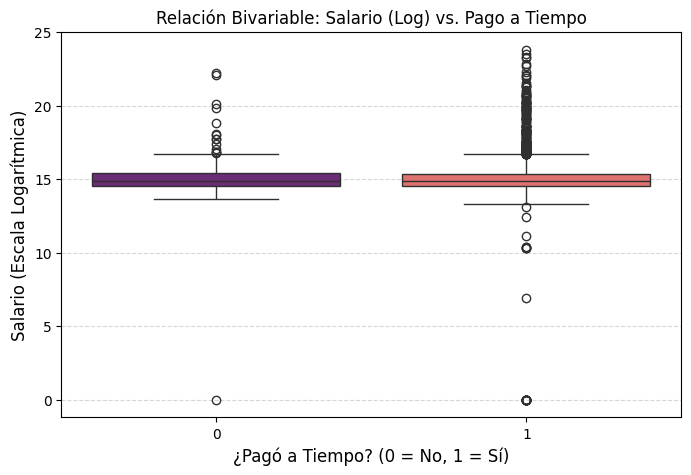

 Medianas de Salario (Log) por grupo:
Pago_atiempo
0    14.914123
1    14.914123
Name: salario_cliente, dtype: float64


In [22]:
# comparación de variable numericas salario_log frente a la variable objetivo

# 1. Configuración del gráfico
plt.figure(figsize=(8, 5))

# 2. Creamos el Boxplot comparativo transformando 'y'
sns.boxplot(
    x='Pago_atiempo', 
    y=np.log1p(df_clean['salario_cliente']), 
    data=df_clean,
    hue='Pago_atiempo',
    palette='magma',
    legend=False
)

plt.title('Relación Bivariable: Salario (Log) vs. Pago a Tiempo', fontsize=12)
plt.xlabel('¿Pagó a Tiempo? (0 = No, 1 = Sí)', fontsize=12)
plt.ylabel('Salario (Escala Logarítmica)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# 3. Resumen numérico
salario_log_temp = np.log1p(df_clean['salario_cliente'])
print(" Medianas de Salario (Log) por grupo:")
print(salario_log_temp.groupby(df_clean['Pago_atiempo'], observed=False).median())

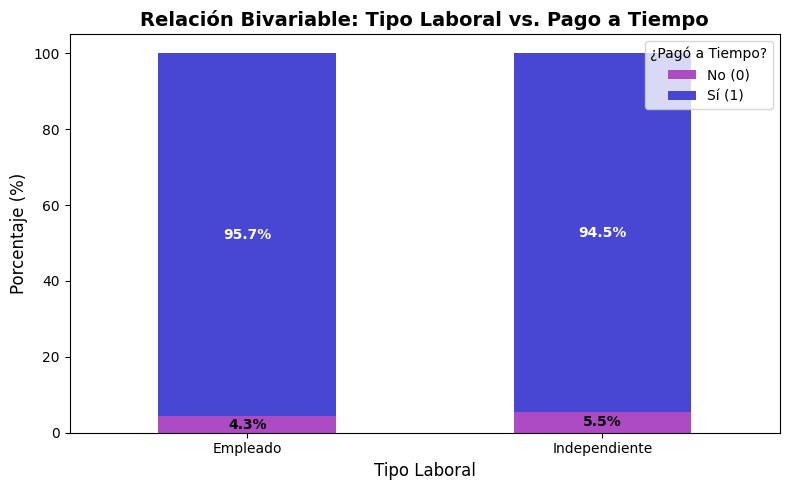

 Tasa de cumplimiento por Tipo Laboral:
Pago_atiempo          0          1
tipo_laboral                      
Empleado       4.293752  95.706248
Independiente  5.512597  94.487403


In [23]:
# comparación de variable categoricas tipo_laboral frente a la variable objetivo

# 1. Creamos la tabla de contingencia (Frecuencias)
tabla_laboral = pd.crosstab(df_clean['tipo_laboral'], df_clean['Pago_atiempo'])

# 2. Convertimos a porcentajes (Frecuencia Relativa) para comparar justamente
tabla_laboral_pct = tabla_laboral.div(tabla_laboral.sum(1), axis=0) * 100

# 3. Gráfico de barras apiladas al 100%
ax = tabla_laboral_pct.plot(kind='bar', stacked=True, figsize=(8, 5), color=["#AC4BC4", "#4747D4"])

plt.title('Relación Bivariable: Tipo Laboral vs. Pago a Tiempo', fontsize=14, fontweight='bold')
plt.xlabel('Tipo Laboral', fontsize=12)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.legend(title='¿Pagó a Tiempo?', labels=['No (0)', 'Sí (1)'], loc='upper right')
plt.xticks(rotation=0)

# Añadir etiquetas de porcentaje dentro de las barras
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0: # Solo poner etiqueta si el segmento es visible
        ax.annotate(f'{height:.1f}%', (x + width/2, y + height/2), 
                    ha='center', va='center', fontsize=10, fontweight='bold', color='white' if height > 50 else 'black')

plt.tight_layout()
plt.show()

# 4. Mostrar la tabla numérica para el reporte
print(" Tasa de cumplimiento por Tipo Laboral:")
print(tabla_laboral_pct)

Transformación de Dataframe agregando variables importantes

In [24]:
# 1. Creamos la copia de seguridad, transformando el dataframe con nuevas variables
df_riesgoCrediticio = df_clean.copy()

# 2. Aplicamos la Ingeniería de Características sobre el nuevo DataFrame
# Relación Cuota-Ingreso (Capacidad de Pago)
# Indica qué porcentaje del sueldo se va en la cuota. Si es > 30%, el riesgo sube.
df_riesgoCrediticio['pct_cuota_sobre_salario'] = (df_riesgoCrediticio['cuota_pactada'] / df_riesgoCrediticio['salario_cliente']).replace([np.inf, -np.inf], 0).fillna(0)

# Endeudamiento Tota Actual
# Sumamos todos los saldos para saber cuánto debe el cliente hoy realmente.
df_riesgoCrediticio['deuda_total_actual'] = df_riesgoCrediticio['saldo_total'] + df_riesgoCrediticio['total_otros_prestamos']

# 3. Uso del Crédito (Apalancamiento)
# Qué tanto del capital prestado ya ha sido pagado.
# (Saldo principal / Capital prestado). Si es cercano a 1, está empezando; si es bajo, ya casi termina.
df_riesgoCrediticio['pct_uso_credito'] = (df_riesgoCrediticio['saldo_principal'] / df_riesgoCrediticio['capital_prestado']).replace([np.inf, -np.inf], 0).fillna(0)

print(f" Nuevo DataFrame 'df_riesgoCrediticio' creado con {len(df_riesgoCrediticio.columns)} columnas.")

 Nuevo DataFrame 'df_riesgoCrediticio' creado con 24 columnas.


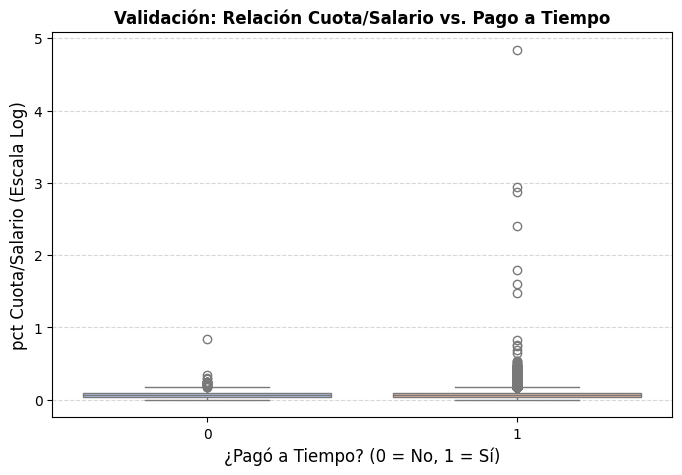

 Mediana del % de carga financiera (Cuota/Salario):
Pago_atiempo
0    6.065167
1    6.075625
Name: pct_cuota_sobre_salario, dtype: float64


In [25]:
# 1. Validación de Capacidad de Pago (Cuota vs Salario)
plt.figure(figsize=(8, 5))

# Usamos logaritmo solo para la visualización porque los porcentajes pueden tener outliers
sns.boxplot(
    x='Pago_atiempo', 
    y=np.log1p(df_riesgoCrediticio['pct_cuota_sobre_salario']), 
    data=df_riesgoCrediticio,
    hue='Pago_atiempo',
    palette='coolwarm',
    legend=False
)

plt.title('Validación: Relación Cuota/Salario vs. Pago a Tiempo', fontsize=12, fontweight='bold')
plt.xlabel('¿Pagó a Tiempo? (0 = No, 1 = Sí)', fontsize=12)
plt.ylabel('pct Cuota/Salario (Escala Log)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# 2. Resumen numérico de la mediana real (sin log para entender el %) (multiplicado por 100 para ver el porcentaje)
print(" Mediana del % de carga financiera (Cuota/Salario):")
resumen_cuota = df_riesgoCrediticio.groupby('Pago_atiempo', observed=False)['pct_cuota_sobre_salario'].median() * 100
print(resumen_cuota)

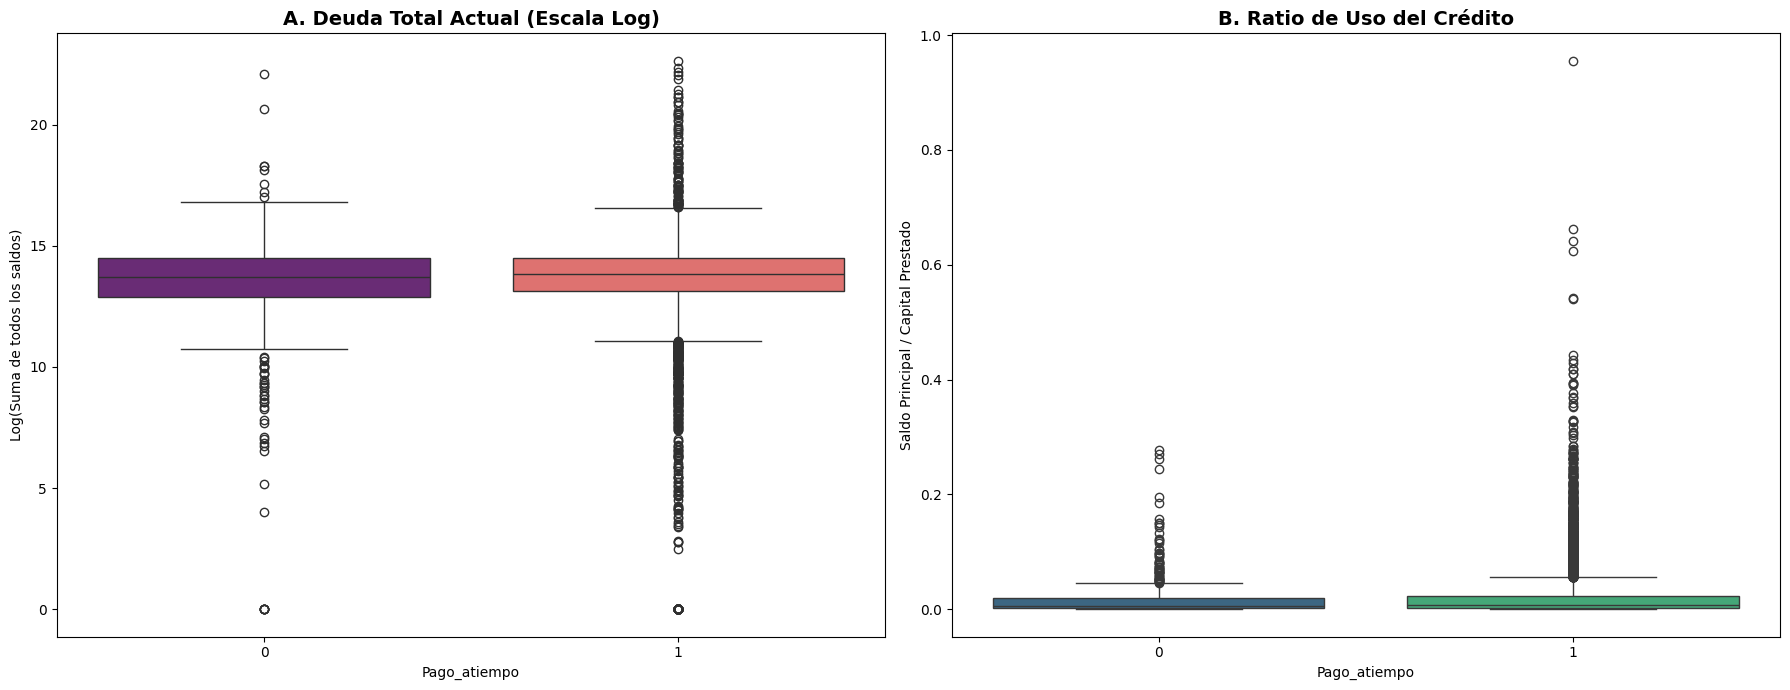

Medianas de las nuevas variables por grupo:
----------------------------------------
Deuda Total Actual (Original):
Pago_atiempo
0     906031.0
1    1008550.5
Name: deuda_total_actual, dtype: float64

Porcentaje de Uso del Crédito:
Pago_atiempo
0    0.005127
1    0.007314
Name: pct_uso_credito, dtype: float64


In [26]:
# 1. Configuración de la figura para dos gráficas
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- GRÁFICA A: Endeudamiento Total Actual ---
sns.boxplot(
    x='Pago_atiempo', 
    y=np.log1p(df_riesgoCrediticio['deuda_total_actual']), 
    data=df_riesgoCrediticio,
    hue='Pago_atiempo',
    palette='magma',
    ax=axes[0],
    legend=False
)
axes[0].set_title('A. Deuda Total Actual (Escala Log)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Log(Suma de todos los saldos)')

# --- GRÁFICA B: Ratio de Uso del Crédito (Apalancamiento) ---
# Esta variable va de 0 a 1, no necesita logaritmo
sns.boxplot(
    x='Pago_atiempo', 
    y='pct_uso_credito', 
    data=df_riesgoCrediticio,
    hue='Pago_atiempo',
    palette='viridis',
    ax=axes[1],
    legend=False
)
axes[1].set_title('B. Ratio de Uso del Crédito', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Saldo Principal / Capital Prestado')

plt.tight_layout()
plt.show()

# 2. Resumen numérico de medianas
print("Medianas de las nuevas variables por grupo:")
print("-" * 40)
print("Deuda Total Actual (Original):")
print(df_riesgoCrediticio.groupby('Pago_atiempo', observed=False)['deuda_total_actual'].median())
print("\nPorcentaje de Uso del Crédito:")
print(df_riesgoCrediticio.groupby('Pago_atiempo', observed=False)['pct_uso_credito'].median())

Analisis Multivariable

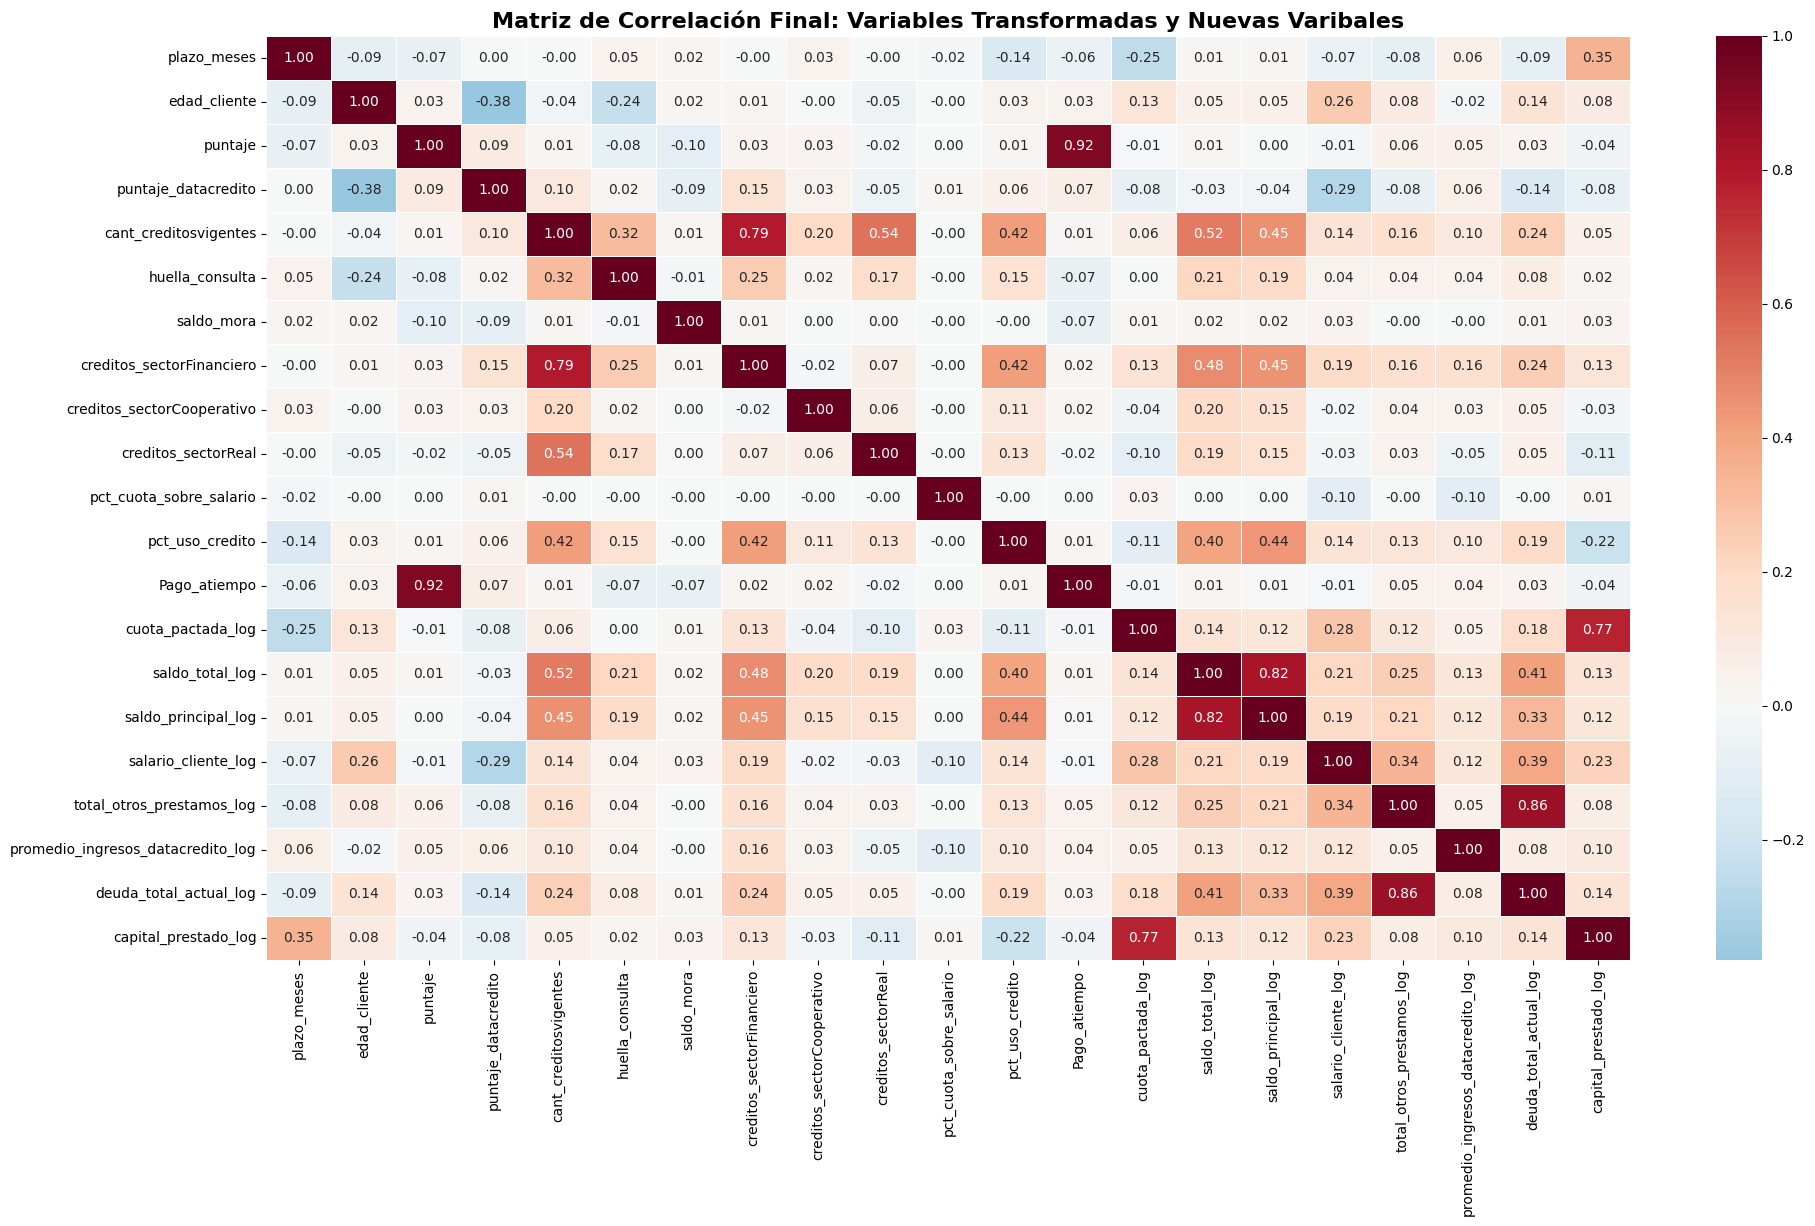

In [27]:
# Seleccionamos solo las variables numéricas e incluimos las nuevas variables para el analisis

# 1. Seleccionamos las columnas numéricas del DataFrame final

# 1. Definimos las variables que necesitan logaritmo (las "salvajes")
cols_salvajes = [
    'cuota_pactada', 'saldo_total', 'saldo_principal', 'salario_cliente',
    'total_otros_prestamos', 'promedio_ingresos_datacredito', 
    'deuda_total_actual', 'capital_prestado'
]

# 2. Creamos una copia temporal para la matriz
df_matriz_final = df_riesgoCrediticio.select_dtypes(include=[np.number]).copy()
# Convertimos el objetivo a entero para que aparezca en la matriz
df_matriz_final['Pago_atiempo'] = df_riesgoCrediticio['Pago_atiempo'].astype(int)

# 3. Aplicamos transformaciones y eliminamos las originales "al vuelo"
for col in cols_salvajes:
    if col in df_matriz_final.columns:
        df_matriz_final[f'{col}_log'] = np.log1p(df_matriz_final[col])
        df_matriz_final.drop(columns=[col], inplace=True)

# 4. Calculamos la correlación
final_corr_matrix = df_matriz_final.corr()

# 5. Graficamos el Heatmap Final
plt.figure(figsize=(22, 12))
sns.heatmap(
    final_corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='RdBu_r', 
    center=0,
    linewidths=0.5
)

plt.title('Matriz de Correlación Final: Variables Transformadas y Nuevas Varibales', fontsize=16, fontweight='bold')
plt.show()

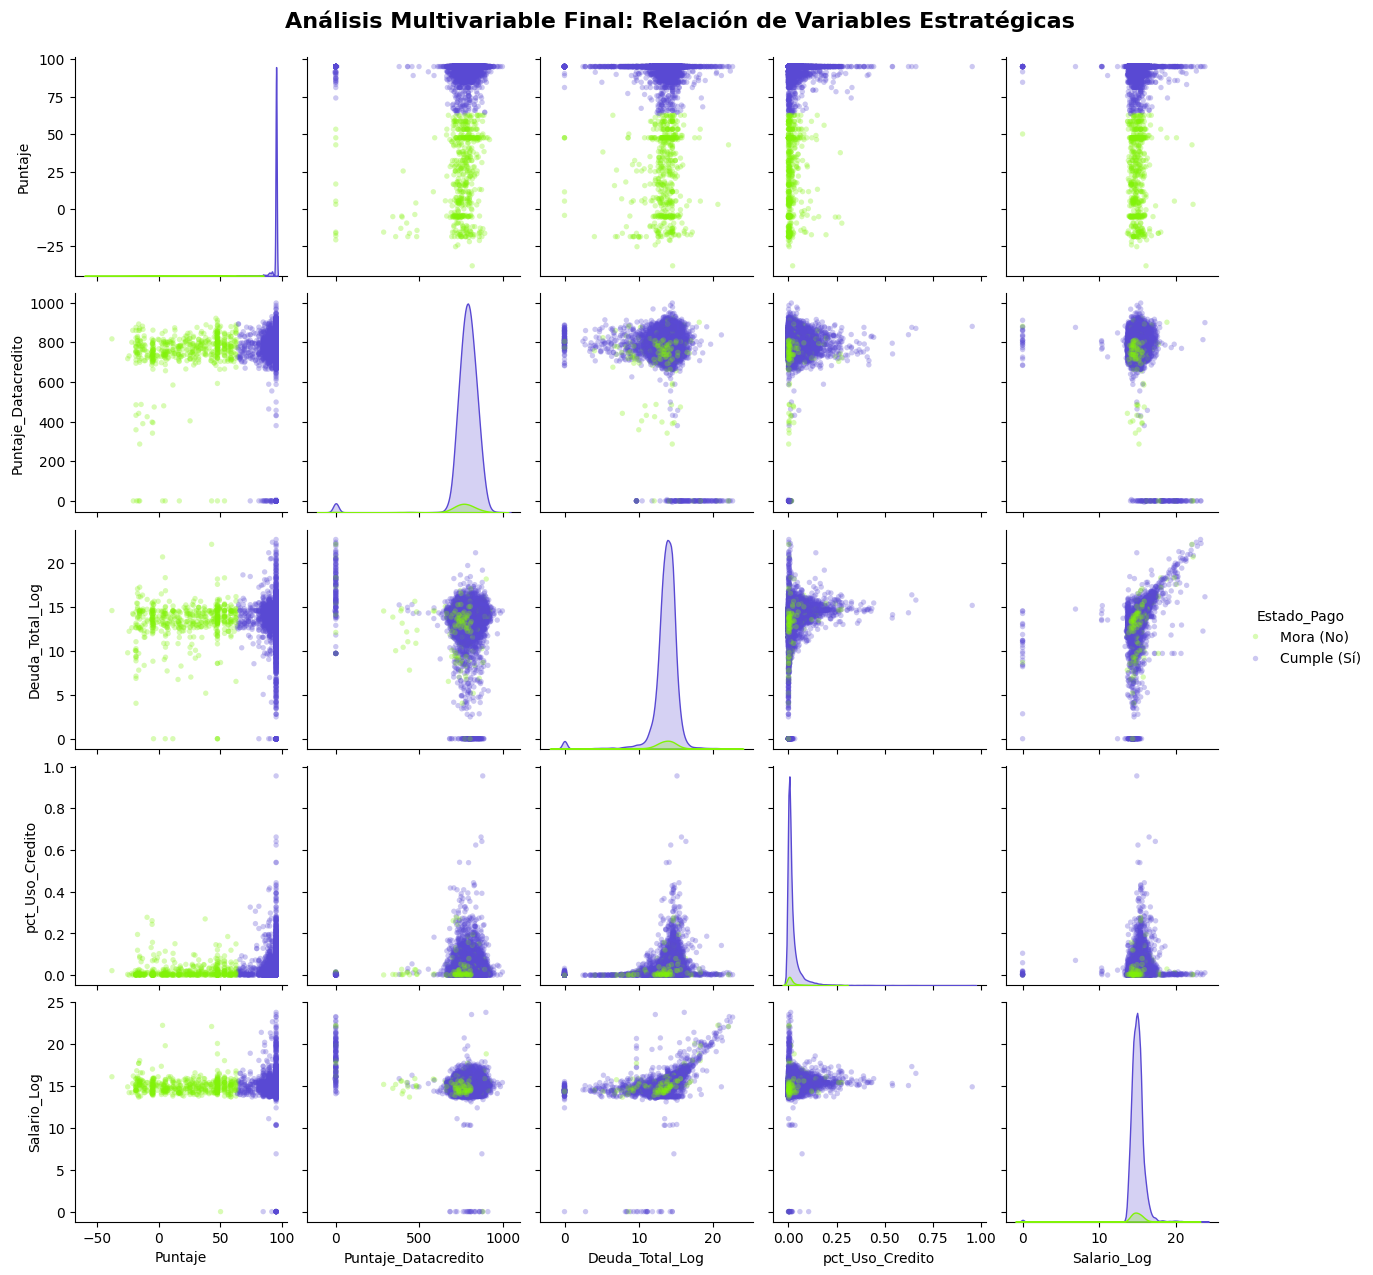

In [28]:
#  Pairplot
# Seleccionamos las variables originales y las creadas que mostraron más interés
df_pair_final = pd.DataFrame({
    'Puntaje': df_riesgoCrediticio['puntaje'],
    'Puntaje_Datacredito': df_riesgoCrediticio['puntaje_datacredito'],
    'Deuda_Total_Log': np.log1p(df_riesgoCrediticio['deuda_total_actual']),
    'pct_Uso_Credito': df_riesgoCrediticio['pct_uso_credito'],
    'Salario_Log': np.log1p(df_riesgoCrediticio['salario_cliente']),
    # Etiquetas claras para la leyenda
    'Estado_Pago': df_riesgoCrediticio['Pago_atiempo'].map({0: 'Mora (No)', 1: 'Cumple (Sí)'})
})

sns.pairplot(
    df_pair_final, 
    hue='Estado_Pago', 
    palette={'Mora (No)': "#81F208", 'Cumple (Sí)': '#5949d3'},
    diag_kind='kde',
    plot_kws={'alpha': 0.3, 's': 15, 'edgecolor': 'none'} # Puntos más suaves para ver densidad
)

plt.suptitle('Análisis Multivariable Final: Relación de Variables Estratégicas', y=1.02, fontsize=16, fontweight='bold')
plt.show()


In [ ]:
# Nulos altos del 27%

# Crear indicadores e imputar
# ---------------------------
# NULOS ALTOS (~27%)
# ---------------------------

# 1. Crear indicadores
df_clean["tendencia_ingresos_null"] = df_clean["tendencia_ingresos"].isnull().astype(int)
df_clean["promedio_ingresos_null"] = df_clean["promedio_ingresos_datacredito"].isnull().astype(int)

# 2. Imputación categórica
df_clean["tendencia_ingresos"] = df_clean["tendencia_ingresos"].fillna("Desconocido")

# 3. Imputación numérica (manteniendo entero)
mediana = int(round(df_clean["promedio_ingresos_datacredito"].median()))
df_clean["promedio_ingresos_datacredito"] = df_clean["promedio_ingresos_datacredito"].fillna(mediana)

print("✅ Imputación avanzada completada")

✅ Imputación avanzada completada
